Part 4 Questions

Packages

In [52]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS

In [35]:
final_df = pd.read_csv("final_df.csv", index_col=0)
final_df.index = pd.PeriodIndex(final_df.index, freq="Q")
# I had this issue when i took the log that some of my values were as -inf and +inf, im just replaincg them with Nan
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

final_df

,ShortRate,ShortRate_Change,PolicyRate,PolicyRate_Change,RealGDP,RealGDP_Log,RealGDP_Log_Change,GDP Deflator_logged,GDP Deflators CPI Proxy,CPI,CPI Log Growth Rate
date,,,,,,,,,,,
1960Q2,4.963333,0.393333,5.333333,0.333333,168948.0,12.037346,-0.006919,1.677209,0.016328,0.606980,2.995429
1960Q3,5.570000,0.606667,6.000000,0.666667,171442.0,12.052000,0.014654,1.676828,-0.000382,0.150830,-1.392346
1960Q4,4.693333,-0.876667,5.333333,-0.666667,172382.0,12.057468,0.005468,1.691078,0.014250,1.054217,1.944403
1961Q1,4.353333,-0.340000,5.000000,-0.333333,175276.0,12.074117,0.016649,1.699609,0.008531,0.536513,-0.675463
1961Q2,4.463333,0.110000,5.000000,0.000000,175974.0,12.078092,0.003974,1.695512,-0.004097,1.245182,0.841947
...,...,...,...,...,...,...,...,...,...,...,...
2016Q1,0.469233,-0.002367,0.500000,0.000000,625099.0,13.345665,0.005021,4.693441,0.005555,-0.298805,NaN
2016Q2,0.423133,-0.046100,0.500000,0.000000,629697.0,13.352994,0.007329,4.696005,0.002564,0.699301,NaN
2016Q3,0.249200,-0.173933,0.333333,-0.166667,632477.0,13.357399,0.004405,4.706035,0.010030,0.396825,-0.566584


Importing the dataframe

### Question 5,6,7 --> Check if there is seasonal adjustment or not: you may regress your time series on seasonal dummies. Check if the scale of the time series is comparable: for example, if monthly inflation is not "annualized" i.e. multiplied by 12 to have an "annual" scale for this monthly data, whereas the monthly Fedís funds rate is multiplied by 12. Then multiply monthly inflation by 12, because in regressions, the ratio of standard errors of each variables will be multiplied or divided by 12 because of these difference of scale. Then the Taylor rule parameter may be multiplied by 12 with monthly or by 4 with quarterly data.

Making my dummy variables

In [36]:
seasonal_dummies_Q4 = pd.get_dummies(final_df.index.to_timestamp().quarter, prefix ="Q", drop_first=True).astype(int)
seasonal_dummies_Q4.index = final_df.index

variables_that_need_g_checking = [
    "CPI Log Growth Rate",
    "CPI",
    "GDP Deflators CPI Proxy",
    "RealGDP_Log_Change",
    "PolicyRate",
    "ShortRate"
]

# Running Simple Seasonal Dummy regression

for vars in variables_that_need_g_checking:
    y = final_df[vars]
    combined = pd.concat([y, seasonal_dummies_Q4], axis=1).dropna()  # <-- joint dropna
    y_clean = combined[vars]
    X_clean = sm.add_constant(combined.drop(columns=vars))
    model = sm.OLS(y_clean, X_clean).fit()
    print(f"\nVariable: {vars}  (n={len(y_clean)})")
    print(f"  Q2 coef: {model.params.get('Q_2', float('nan')):.4f} | p-val: {model.pvalues.get('Q_2', float('nan')):.4f}")
    print(f"  Q3 coef: {model.params.get('Q_3', float('nan')):.4f} | p-val: {model.pvalues.get('Q_3', float('nan')):.4f}")
    print(f"  Q4 coef: {model.params.get('Q_4', float('nan')):.4f} | p-val: {model.pvalues.get('Q_4', float('nan')):.4f}")
    print(f"  --> Seasonality present: {any(model.pvalues[1:] < 0.05)}")



Variable: CPI Log Growth Rate  (n=189)
  Q2 coef: 1.1445 | p-val: 0.0000
  Q3 coef: -0.8134 | p-val: 0.0000
  Q4 coef: 0.7192 | p-val: 0.0000
  --> Seasonality present: True

Variable: CPI  (n=228)
  Q2 coef: 0.9886 | p-val: 0.0001
  Q3 coef: -0.3324 | p-val: 0.1792
  Q4 coef: 0.0568 | p-val: 0.8181
  --> Seasonality present: True

Variable: GDP Deflators CPI Proxy  (n=228)
  Q2 coef: -0.0003 | p-val: 0.9013
  Q3 coef: 0.0016 | p-val: 0.5542
  Q4 coef: 0.0012 | p-val: 0.6469
  --> Seasonality present: False

Variable: RealGDP_Log_Change  (n=228)
  Q2 coef: 0.0008 | p-val: 0.6523
  Q3 coef: -0.0004 | p-val: 0.8396
  Q4 coef: -0.0002 | p-val: 0.9261
  --> Seasonality present: False

Variable: PolicyRate  (n=228)
  Q2 coef: -0.1854 | p-val: 0.8095
  Q3 coef: 0.0191 | p-val: 0.9802
  Q4 coef: 0.0946 | p-val: 0.9020
  --> Seasonality present: False

Variable: ShortRate  (n=228)
  Q2 coef: -0.0893 | p-val: 0.9038
  Q3 coef: 0.1385 | p-val: 0.8513
  Q4 coef: 0.1399 | p-val: 0.8499
  --> Seas

Checking Scalability

          CPI Log Growth Rate       CPI  GDP Deflators CPI Proxy  \
count                189.0000  228.0000                 228.0000   
mean                   0.0143    1.2911                   0.0134   
std                    1.0141    1.3978                   0.0143   
min                   -2.6418   -0.7056                  -0.0237   
25%                   -0.7055    0.4393                   0.0041   
50%                    0.1354    0.9202                   0.0107   
75%                    0.5999    1.6942                   0.0186   
max                    2.9954    9.4510                   0.0730   
skew                  -0.0298    2.1484                   1.3260   
kurtosis               0.1368    6.6135                   2.8913   

          RealGDP_Log_Change  PolicyRate  ShortRate  
count               228.0000    228.0000   228.0000  
mean                  0.0058      6.9371     6.5884  
std                   0.0095      4.0735     3.9154  
min                  -0.0281      0

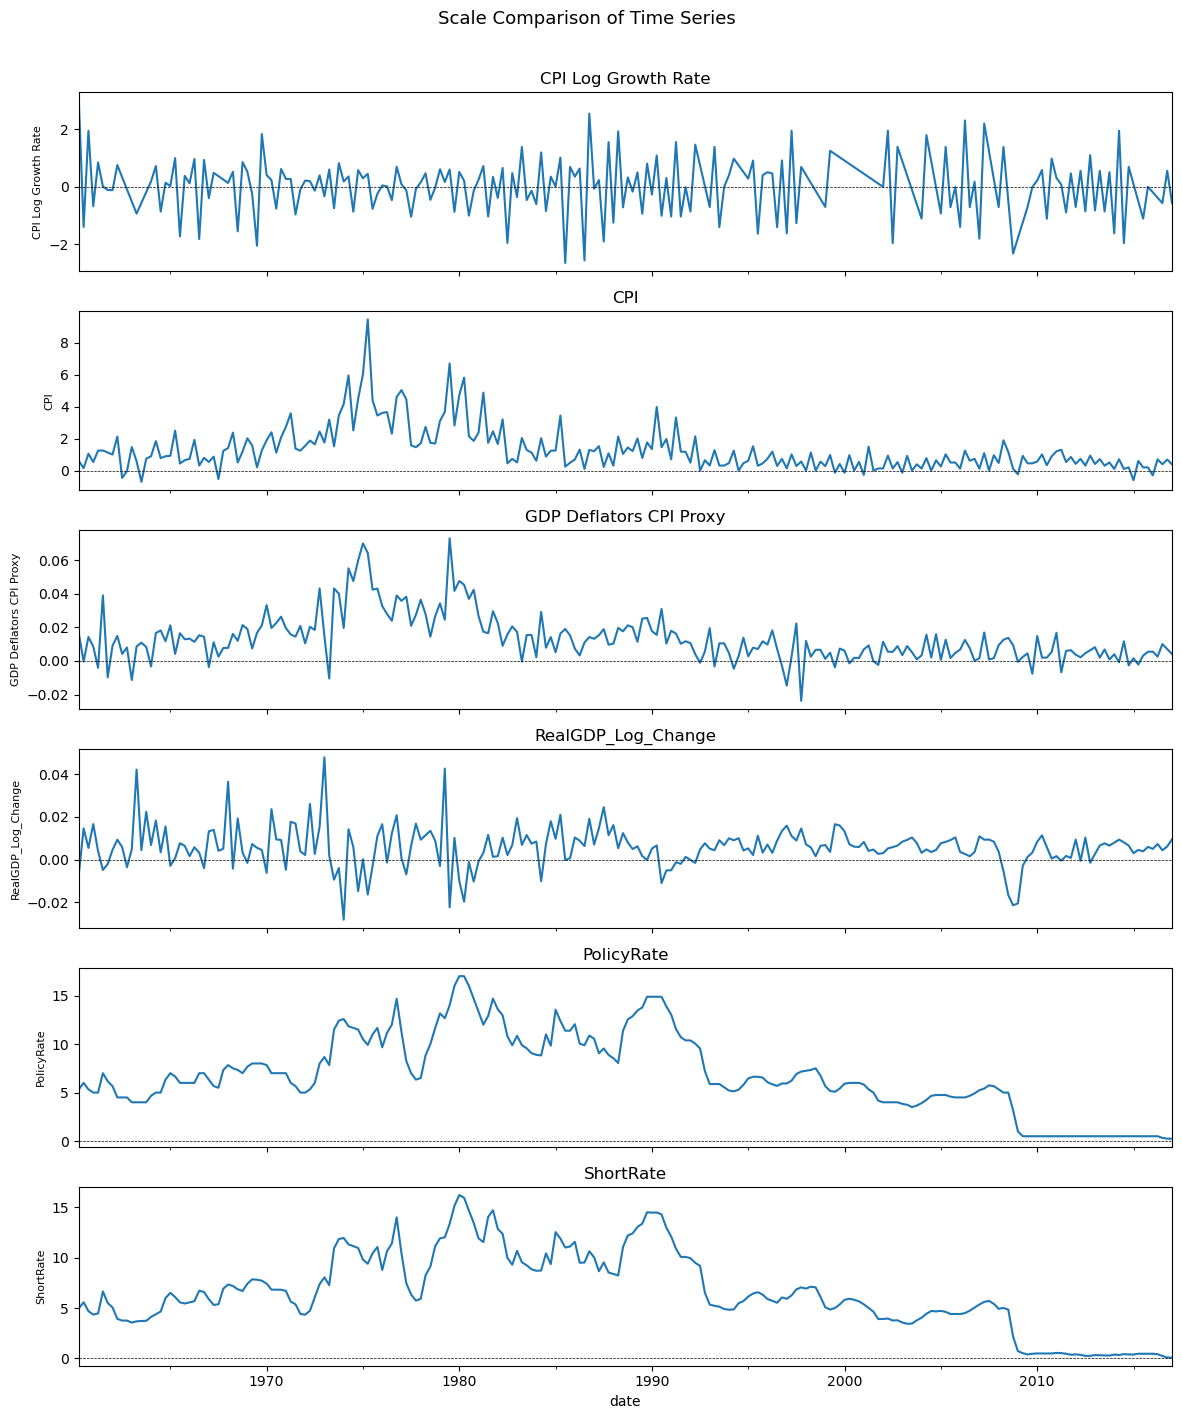

In [ ]:
scale_vars = [
    "CPI Log Growth Rate",
    "CPI",
    "GDP Deflators CPI Proxy",
    "RealGDP_Log_Change",
    "PolicyRate",
    "ShortRate"
]

# Descriptive stats with skew and kurtosis
desc = final_df[scale_vars].describe().round(4)
skew = final_df[scale_vars].skew().rename("skew").round(4)
kurt = final_df[scale_vars].kurt().rename("kurtosis").round(4)
dezzy_stats = pd.concat([desc, skew.to_frame().T, kurt.to_frame().T])
print(dezzy_stats)

# Visual check — plot all series to eyeball scale differences
fig, axes = plt.subplots(len(scale_vars), 1, figsize=(12, 14), sharex=True)

for ax, var in zip(axes, scale_vars):
    final_df[var].dropna().plot(ax=ax, title=var)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_ylabel(var, fontsize=8)

plt.suptitle("Scale Comparison of Time Series", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Annualising Quarterly Inflation 


Std Dev BEFORE annualising:
CPI Log Growth Rate    1.0141
PolicyRate             4.0735
ShortRate              3.9154
dtype: float64

Std Dev AFTER annualising:
CPI_Inflation_Annualised    5.5913
PolicyRate                  4.0735
ShortRate                   3.9154
dtype: float64


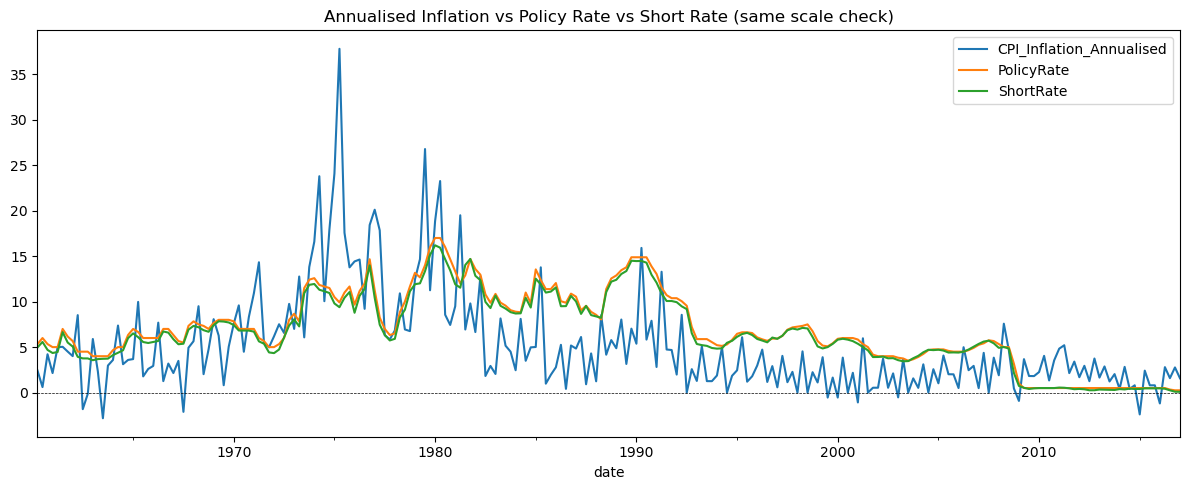

In [ ]:
final_df["CPI_Inflation_Annualised"]         = final_df["CPI"] * 4
final_df["GDP_Deflator_Inflation_Annualised"] = final_df["GDP Deflators CPI Proxy"] * 4
final_df["RealGDP_Growth_Annualised"]         = final_df["RealGDP_Log_Change"] * 4

# Check std devs before and after to confirm scale alignment
print("\nStd Dev BEFORE annualising:")
print(final_df[["CPI Log Growth Rate", "PolicyRate", "ShortRate"]].std().round(4))

print("\nStd Dev AFTER annualising:")
print(final_df[["CPI_Inflation_Annualised", "PolicyRate", "ShortRate"]].std().round(4))

# Quick plot to confirm annualised inflation is now on same scale as rates
final_df[["CPI_Inflation_Annualised", "PolicyRate", "ShortRate"]].dropna().plot(
    figsize=(12, 5),
    title="Annualised Inflation vs Policy Rate vs Short Rate (same scale check)"
)
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

Question 8

AR(1) = pi_t = Api_t-1 + u_t

In [73]:
# My Two parameter valuees 
pi = pd.to_numeric(final_df["CPI"], errors="coerce").dropna()
i_rate = pd.to_numeric(final_df["PolicyRate"], errors="coerce").dropna()

pi_lagged = pi.shift(1)

# AR(1)
ar1_pi = pd.concat([pi, pi_lagged], axis=1).dropna()
ar1_pi.columns = ["pi_t1", "pi_t"]

# Adding an intercept so that i can catch dev's from the steady state and mean ygm
X_pi = sm.add_constant(ar1_pi["pi_t"])
y_pi = ar1_pi["pi_t1"]

# Estimate AR(1) for inflation
ar1_pi_model = OLS(y_pi.reset_index(drop=True),X_pi.reset_index(drop=True)).fit()

print("AR(1) — Inflation (π)")
print(ar1_pi_model.summary())
print(f"\n λ_π estimate: {ar1_pi_model.params['pi_t']:.4f}")


AR(1) — Inflation (π)
                            OLS Regression Results                            
Dep. Variable:                  pi_t1   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     143.3
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           7.12e-26
Time:                        16:55:31   Log-Likelihood:                -342.08
No. Observations:                 227   AIC:                             688.2
Df Residuals:                     225   BIC:                             695.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4860      0.0

AR(1) - Residuals

In [74]:
u_pi = ar1_pi_model.resid
u_pi_lag = u_pi.shift(1)

ar1_resid_pi = pd.concat([u_pi, u_pi_lag], axis=1).dropna()
ar1_resid_pi.columns = ["u_t1", "u_t"]

# Add intercept
X_u_pi = sm.add_constant(ar1_resid_pi["u_t"])
y_u_pi = ar1_resid_pi["u_t1"]


ar1_resid_pi_model = OLS(y_u_pi.reset_index(drop=True), X_u_pi.reset_index(drop=True)).fit()


print("AR(1) Residual Autocorrelation — Inflation (ρ_π)")

print(ar1_resid_pi_model.summary())
print(f"\n ρ_π estimate: {ar1_resid_pi_model.params['u_t']:.4f}")

AR(1) Residual Autocorrelation — Inflation (ρ_π)
                            OLS Regression Results                            
Dep. Variable:                   u_t1   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     12.00
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           0.000638
Time:                        16:57:53   Log-Likelihood:                -334.96
No. Observations:                 226   AIC:                             673.9
Df Residuals:                     224   BIC:                             680.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

Ar(1) intrest rate 

In [ ]:
i_rate = final_df["PolicyRate"].dropna()

i_lag = i_rate.shift(1)

ar1_i = pd.concat([i_rate, i_lag], axis=1).dropna()
ar1_i.columns = ["i_t1", "i_t"]

X_i = sm.add_constant(ar1_i["i_t"])
y_i = ar1_i["i_t1"]

ar1_i_model = OLS(y_i.reset_index(drop=True),X_i.reset_index(drop=True)).fit()


print("AR(1) — Interest Rate (i)")
print(ar1_i_model.summary())
print(f"\n λ_i estimate: {ar1_i_model.params['i_t']:.4f}")



AR(1) — Interest Rate (i)
                            OLS Regression Results                            
Dep. Variable:                   i_t1   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     4245.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          4.92e-148
Time:                        16:58:32   Log-Likelihood:                -301.57
No. Observations:                 227   AIC:                             607.1
Df Residuals:                     225   BIC:                             614.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1167    

AR(1) on the residuals of interest rate AR(1)

In [76]:
u_i = ar1_i_model.resid

u_i_lag = u_i.shift(1)

ar1_resid_i = pd.concat([u_i, u_i_lag], axis=1).dropna()
ar1_resid_i.columns = ["u_t1", "u_t"]

X_u_i = sm.add_constant(ar1_resid_i["u_t"])
y_u_i = ar1_resid_i["u_t1"]

ar1_resid_i_model = OLS(y_u_i.reset_index(drop=True),X_u_i.reset_index(drop=True)).fit()

print("AR(1) Residual Autocorrelation — Interest Rate (ρ_i)")
print(ar1_resid_i_model.summary())
print(f"\n ρ_i estimate: {ar1_resid_i_model.params['u_t']:.4f}")

AR(1) Residual Autocorrelation — Interest Rate (ρ_i)
                            OLS Regression Results                            
Dep. Variable:                   u_t1   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     9.102
Date:                Sat, 14 Mar 2026   Prob (F-statistic):            0.00285
Time:                        16:59:37   Log-Likelihood:                -295.98
No. Observations:                 226   AIC:                             596.0
Df Residuals:                     224   BIC:                             602.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

Big old summary table 

In [77]:
summary_table = pd.DataFrame({
    "Parameter": ["λ_π", "ρ_π", "λ_i", "ρ_i"],
    "Estimate":  [
        ar1_pi_model.params["pi_t"],
        ar1_resid_pi_model.params["u_t"],
        ar1_i_model.params["i_t"],
        ar1_resid_i_model.params["u_t"]
    ],
    "p-value": [
        ar1_pi_model.pvalues["pi_t"],
        ar1_resid_pi_model.pvalues["u_t"],
        ar1_i_model.pvalues["i_t"],
        ar1_resid_i_model.pvalues["u_t"]
    ]
}).round(4)

print("\n" + "=" * 60)
print("SUMMARY — AR(1)-AR(1) Parameters")
print("=" * 60)
print(summary_table.to_string(index=False))


SUMMARY — AR(1)-AR(1) Parameters
Parameter  Estimate  p-value
      λ_π    0.6240   0.0000
      ρ_π   -0.2254   0.0006
      λ_i    0.9800   0.0000
      ρ_i    0.1974   0.0028
